# F1-RaceIQ-Suite: Ensemble Methods — Random Forest & XGBoost


 compares two Ensemble models — **Random Forest** and **XGBoost** — to predict whether a driver will finish in the **Top 10 (Points)** or **Outside Top 10 (No Points)**.



## Step 1 — Import Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_score,
                              recall_score, f1_score)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 2 — Load the Cleaned Dataset



In [2]:
df = pd.read_csv('cleaned_f1_data.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 6939 rows, 19 columns


,Season,Round,Race Name,Date,Circuit,Country,Latitude,Longitude,Driver,Driver Nationality,Driver Age,Constructor,Grid Position,Race Position,Points Earned,Fastest Lap (s),Fastest Lap Rank,Laps Completed,Status
0,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Nino Farina,Italian,44,Alfa Romeo,1,1,9.0,90.239026,-1,70,Finished
1,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Reg Parnell,British,39,Alfa Romeo,4,3,4.0,90.239026,-1,70,Finished
2,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Yves Cabantous,French,46,Talbot-Lago,6,4,3.0,90.239026,-1,68,+2 Laps
3,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Louis Rosier,French,45,Talbot-Lago,9,5,2.0,90.239026,-1,68,+2 Laps
4,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Bob Gerard,British,36,ERA,13,6,0.0,90.239026,-1,67,+3 Laps


## Step 3 — Drop Irrelevant Columns



In [3]:
to_drop = ['Season', 'Round', 'Race Name', 'Date', 'Country',
           'Driver Nationality', 'Driver', 'Points Earned',
           'Latitude', 'Longitude']

df = df.drop(columns=to_drop, errors='ignore')
print("Remaining columns:", list(df.columns))
print("Shape after dropping:", df.shape)

Remaining columns: ['Circuit', 'Driver Age', 'Constructor', 'Grid Position', 'Race Position', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed', 'Status']
Shape after dropping: (6939, 9)


## Step 4 — Feature Engineering (Binary Features)



In [4]:
df['Grid Position Binary'] = (df['Grid Position'] <= 10).astype(int)
df['Driver Age Binary'] = (df['Driver Age'] > 30).astype(int)
df['Laps Completed Binary'] = (df['Laps Completed'] > 50).astype(int)

df = df.drop(['Grid Position', 'Driver Age', 'Laps Completed'], axis=1)
print("Binary features created.")
print("Columns now:", list(df.columns))

Binary features created.
Columns now: ['Circuit', 'Constructor', 'Race Position', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Status', 'Grid Position Binary', 'Driver Age Binary', 'Laps Completed Binary']


## Step 5 — Encode Categorical Columns



In [5]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

categories_list = [df[col].unique().tolist() for col in categorical_cols]
encoder = OrdinalEncoder(categories=categories_list)
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

print("Encoding complete.")
df.head()

Categorical columns to encode: ['Circuit', 'Constructor', 'Status']
Encoding complete.


,Circuit,Constructor,Race Position,Fastest Lap (s),Fastest Lap Rank,Status,Grid Position Binary,Driver Age Binary,Laps Completed Binary
0,0.0,0.0,1,90.239026,-1,0.0,1,1,1
1,0.0,0.0,3,90.239026,-1,0.0,1,1,1
2,0.0,1.0,4,90.239026,-1,1.0,1,1,1
3,0.0,1.0,5,90.239026,-1,1.0,1,1,1
4,0.0,2.0,6,90.239026,-1,2.0,0,1,1


## Step 6 — Define the Target Variable



In [6]:
df['Position_Category'] = (df['Race Position'] <= 10).astype(int)
df = df.drop(['Race Position'], axis=1)

print("Target variable distribution:")
print(df['Position_Category'].value_counts())
total = len(df)
points = df['Position_Category'].sum()
print(f"\nClass balance: {points/total*100:.1f}% Points, {(total-points)/total*100:.1f}% No Points")

Target variable distribution:
Position_Category
0    3590
1    3349
Name: count, dtype: int64

Class balance: 48.3% Points, 51.7% No Points


## Step 7 — Train/Test Split (80/20)



In [7]:
X = df.drop(['Position_Category'], axis=1)
y = df['Position_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Features:     {X_train.shape[1]} columns")
print(f"\nFeature names: {list(X.columns)}")

Training set: 5551 rows
Test set:     1388 rows
Features:     8 columns

Feature names: ['Circuit', 'Constructor', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Status', 'Grid Position Binary', 'Driver Age Binary', 'Laps Completed Binary']


## Step 8 — Feature Scaling (StandardScaler)

 Normalising all numeric features so they have a mean of 0 and standard deviation of 1.

 Unlike Decision Trees which split on thresholds and are scale-independent, XGBoost's gradient descent optimisation converges faster when features are on a similar scale. For example `Fastest Lap (s)` ranges 65–150 while `Driver Age Binary` is just 0 or 1 — without scaling the larger-ranged feature dominates.



In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling — sample values from first training row:")
print(dict(zip(X.columns, X_train.iloc[0].values)))
print("\nAfter scaling — same row:")
print(dict(zip(X.columns, X_train_scaled[0].round(3))))

Before scaling — sample values from first training row:
{'Circuit': np.float64(22.0), 'Constructor': np.float64(111.0), 'Fastest Lap (s)': np.float64(88.84585261013103), 'Fastest Lap Rank': np.float64(-1.0), 'Status': np.float64(6.0), 'Grid Position Binary': np.float64(1.0), 'Driver Age Binary': np.float64(1.0), 'Laps Completed Binary': np.float64(1.0)}

After scaling — same row:
{'Circuit': np.float64(0.261), 'Constructor': np.float64(0.622), 'Fastest Lap (s)': np.float64(0.0), 'Fastest Lap Rank': np.float64(-0.547), 'Status': np.float64(-0.435), 'Grid Position Binary': np.float64(1.037), 'Driver Age Binary': np.float64(1.111), 'Laps Completed Binary': np.float64(0.79)}


## Step 9 — Random Forest Classifier



In [9]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("=" * 50)
print("RANDOM FOREST — Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Points', 'Points']))

RANDOM FOREST — Results
Accuracy:  0.8732
Precision: 0.8678
Recall:    0.8652
F1 Score:  0.8665

Classification Report:
              precision    recall  f1-score   support

   No Points       0.88      0.88      0.88       728
      Points       0.87      0.87      0.87       660

    accuracy                           0.87      1388
   macro avg       0.87      0.87      0.87      1388
weighted avg       0.87      0.87      0.87      1388



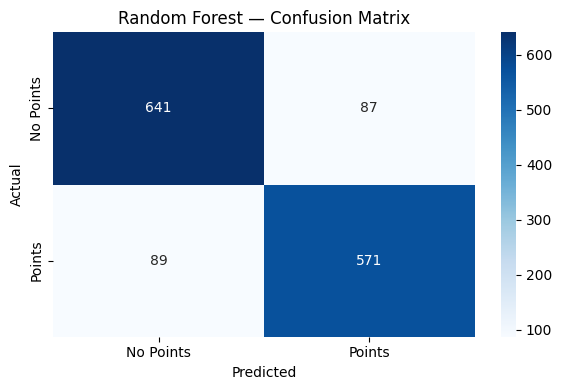

In [10]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 10 — Random Forest Feature Importance



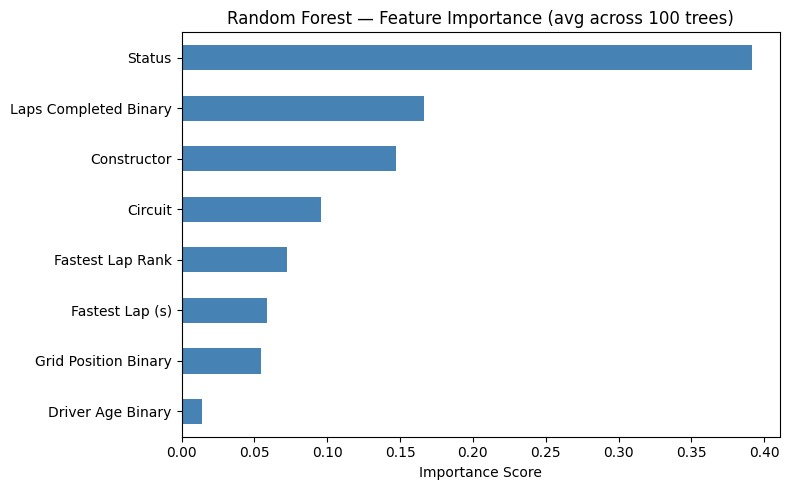


Feature Importance scores:
Status                   0.391246
Laps Completed Binary    0.166201
Constructor              0.147274
Circuit                  0.095419
Fastest Lap Rank         0.072385
Fastest Lap (s)          0.058875
Grid Position Binary     0.054657
Driver Age Binary        0.013943
dtype: float64


In [11]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importance (avg across 100 trees)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature Importance scores:")
print(importances.sort_values(ascending=False))

## Step 11 — XGBoost Classifier



In [12]:
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("=" * 50)
print("XGBOOST — Results")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['No Points', 'Points']))

XGBOOST — Results
Accuracy:  0.8833
Precision: 0.8761
Recall:    0.8788
F1 Score:  0.8775

Classification Report:
              precision    recall  f1-score   support

   No Points       0.89      0.89      0.89       728
      Points       0.88      0.88      0.88       660

    accuracy                           0.88      1388
   macro avg       0.88      0.88      0.88      1388
weighted avg       0.88      0.88      0.88      1388



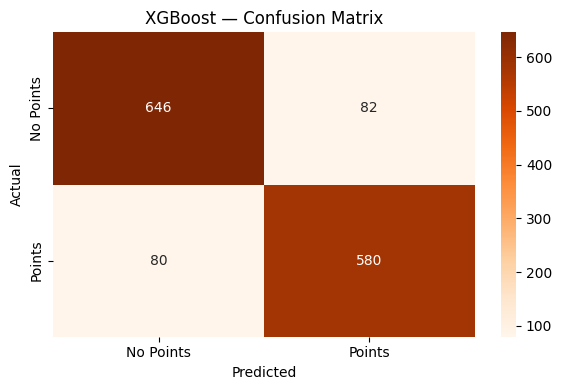

In [13]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 12 — XGBoost Feature Importance



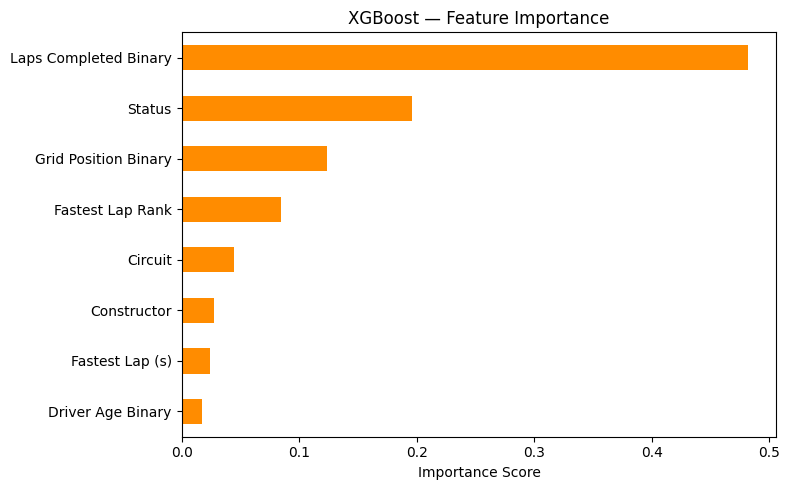


XGBoost Feature Importance scores:
Laps Completed Binary    0.481853
Status                   0.195740
Grid Position Binary     0.123552
Fastest Lap Rank         0.084796
Circuit                  0.044940
Constructor              0.027547
Fastest Lap (s)          0.024184
Driver Age Binary        0.017387
dtype: float32


In [14]:
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
xgb_importances = xgb_importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
xgb_importances.plot(kind='barh', color='darkorange')
plt.title('XGBoost — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nXGBoost Feature Importance scores:")
print(xgb_importances.sort_values(ascending=False))

## Step 13 — Model Comparison: Random Forest vs XGBoost



In [15]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy':  [accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_rf),
                  precision_score(y_test, y_pred_xgb)],
    'Recall':    [recall_score(y_test, y_pred_rf),
                  recall_score(y_test, y_pred_xgb)],
    'F1 Score':  [f1_score(y_test, y_pred_rf),
                  f1_score(y_test, y_pred_xgb)]
})

print(results.to_string(index=False))

        Model  Accuracy  Precision   Recall  F1 Score
Random Forest  0.873199   0.867781 0.865152  0.866464
      XGBoost  0.883285   0.876133 0.878788  0.877458


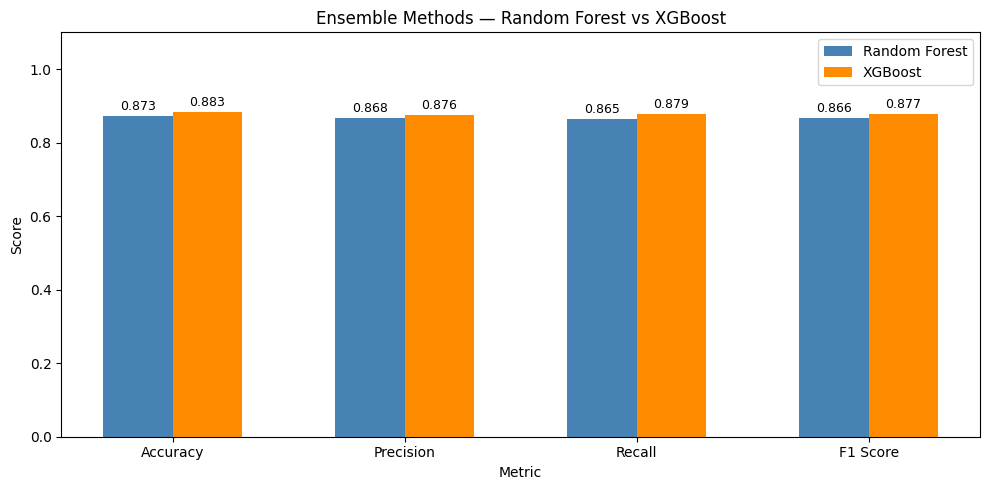

In [16]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, results.iloc[0][metrics], width,
               label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, results.iloc[1][metrics], width,
               label='XGBoost', color='darkorange')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Ensemble Methods — Random Forest vs XGBoost')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=9)
plt.tight_layout()
plt.show()

## Step 14 — Side-by-Side Feature Importance Comparison


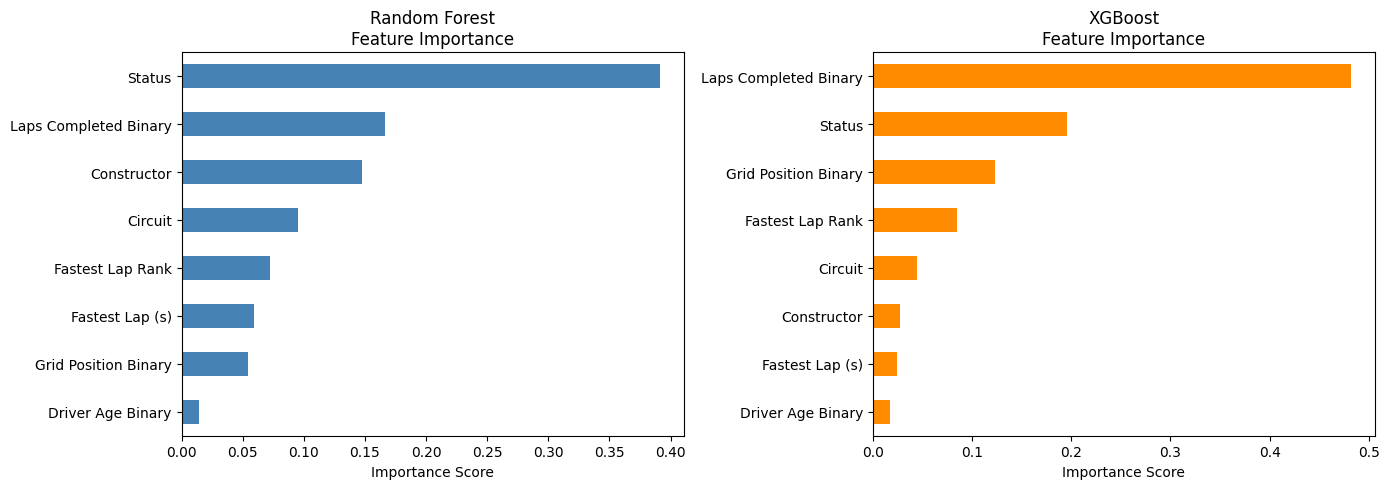

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)

rf_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest\nFeature Importance')
axes[0].set_xlabel('Importance Score')

xgb_imp.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost\nFeature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()



1. Loaded the same cleaned F1 dataset as the Decision Tree notebook
2. Applied identical preprocessing (same columns dropped, binary features, encoding, 80/20 split)
3. Added **StandardScaler** normalisation — new step vs Decision Tree, needed for XGBoost
4. Trained and evaluated **Random Forest** (100 trees, bagging/parallel approach)
5. Trained and evaluated **XGBoost** (sequential boosting approach)
6. Compared both models across Accuracy, Precision, Recall, and F1-Score
7. Compared feature importances across both models

**Key concepts demonstrated:**
- **Bagging (Random Forest)** — parallel independent trees reduce variance and overfitting
- **Boosting (XGBoost)** — sequential trees each correct previous errors, reduces bias
- **Why ensemble > single tree** — combining many models reduces the weaknesses of any individual model

